**CHAPTER 5**
**FEATURE ENGINEERING PADA DATA KOMENTAR TIKTOK**

Nama: Tabrizzi Aqlia
NIM: 25031554008

Pada Exercise 5 ini, saya menerapkan seluruh metode feature engineering pada teks hasil preprocessing Chapter 4 (kolom prepro dari komentar TikTok). Metode yang digunakan adalah One Hot Encoding, Bag of Words, TF-IDF, Word2Vec, dan FastText. Hasil setiap metode kemudian dibandingkan dan dianalisis.

**Install & import**

In [3]:
!pip install -q gensim

import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gensim.models
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

**Ambil data hasil Chapter 4**

In [14]:
import os

try:
    df = hasil_tiktok.copy()
except NameError:
    for path in ['hasil_tiktok.csv', 'sample_data/hasil_tiktok.csv']:
        if os.path.exists(path):
            df = pd.read_csv(path)
            print("Data dibaca dari:", path)
            break
    else:
        raise FileNotFoundError("hasil_tiktok.csv tidak ditemukan, upload dulu ke Colab")

df = df.dropna(subset=['prepro']).copy()
df['prepro'] = df['prepro'].astype(str).str.strip()
df = df[df['prepro'] != ''].reset_index(drop=True)

docs = df['prepro']
print("Jumlah komentar yang dipakai:", len(df))
df[['text_original', 'prepro']].head(1200)

Data dibaca dari: sample_data/hasil_tiktok.csv
Jumlah komentar yang dipakai: 1265


,text_original,prepro
0,AGUSTUS JAHAT.,agustus jahat
1,monyet nya gimana ya,monyet nya gimana
2,kondisi hewannya gimana termasuk ini?,kondisi hewan gimana masuk
3,"yaallah kasian banget hewan hewan disana, leka...",yaallah kasi banget hewan hewan sana lekas pul...
4,semoga cepat hujan ya kalimantan,moga cepat hujan kalimantan
...,...,...
1195,nanti jangan salahin mereka ya man-temannn🥹 ka...,jangan salahin mantemannn kalau ikut silaturah...
1196,Bali juga kebakaran... 🥺 perasaan makin kesini...,bal bakar asa makin kesini makin sering bencan...
1197,entah la.. tiap tahun mcm ni.. elok lah dpt ta...,entah la tiap tahun mcm ni elok lah dpt tangka...
1198,"Sekelas negara besar,, pemimpinnya jago koar k...",kelas negara besar pimpin jago koar koar jabat...


**1. One Hot Encoding**

Setiap kata bernilai 1 jika muncul dalam komentar dan 0 jika tidak. Berapa kali kata muncul tidak diperhitungkan.

**One Hot Encoding**

In [23]:
ohe_vec = CountVectorizer(binary=True)
X_ohe = ohe_vec.fit_transform(docs)
df_ohe = pd.DataFrame(X_ohe.toarray(), columns=ohe_vec.get_feature_names_out())

print("Ukuran matriks One Hot:", df_ohe.shape)
df_ohe.head(1200)

Ukuran matriks One Hot: (1265, 2986)


,aaku,aamiiin,aamiin,aamiinsemoga,abadi,abai,abis,abrek,abu,ac,...,yimak,yng,yra,yrb,ysca,yups,yuu,zaman,zamanada,zolim
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1196,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1197,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1198,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**2. Bag of Words**

Setiap sel berisi jumlah kemunculan kata dalam satu komentar.

**Bag of Words**

In [19]:
bow_vec = CountVectorizer()
X_bow = bow_vec.fit_transform(docs)
df_bow = pd.DataFrame(X_bow.toarray(), columns=bow_vec.get_feature_names_out())

print("Ukuran matriks BoW:", df_bow.shape)
df_bow.head(1200)

Ukuran matriks BoW: (1265, 2986)


,aaku,aamiiin,aamiin,aamiinsemoga,abadi,abai,abis,abrek,abu,ac,...,yimak,yng,yra,yrb,ysca,yups,yuu,zaman,zamanada,zolim
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1196,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1197,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1198,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**3. TF-IDF**

Bobot kata dihitung dari seberapa sering kata muncul dalam satu komentar (TF) dikali seberapa jarang kata itu muncul di seluruh komentar (IDF).

**TF-IDF**

In [20]:
tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(docs)
df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vec.get_feature_names_out())

print("Ukuran matriks TF-IDF:", df_tfidf.shape)
df_tfidf.head(1200)

Ukuran matriks TF-IDF: (1265, 2986)


,aaku,aamiiin,aamiin,aamiinsemoga,abadi,abai,abis,abrek,abu,ac,...,yimak,yng,yra,yrb,ysca,yups,yuu,zaman,zamanada,zolim
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1196,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1197,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1198,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Analisis One Hot, BoW, dan TF-IDF**

**Ringkasan ukuran dan sparsity**

In [24]:
def ringkas(nama, X):
    total = X.shape[0] * X.shape[1]
    nol = total - X.nnz
    return {
        'Metode': nama,
        'Jumlah dokumen': X.shape[0],
        'Jumlah fitur (kata unik)': X.shape[1],
        'Sel bernilai 0 (%)': round(nol / total * 100, 2)
    }

ringkasan = pd.DataFrame([
    ringkas('One Hot Encoding', X_ohe),
    ringkas('Bag of Words', X_bow),
    ringkas('TF-IDF', X_tfidf),
])
ringkasan

,Metode,Jumlah dokumen,Jumlah fitur (kata unik),Sel bernilai 0 (%)
0,One Hot Encoding,1265,2986,99.7
1,Bag of Words,1265,2986,99.7
2,TF-IDF,1265,2986,99.7


**Top 100 kata per metode**

In [40]:
top_ohe = df_ohe.sum().sort_values(ascending=False).head(100)
top_bow = df_bow.sum().sort_values(ascending=False).head(100)
top_tfidf = df_tfidf.mean().sort_values(ascending=False).head(100)

print("Top 100 kata berdasarkan jumlah komentar yang memuatnya (One Hot):")
display(top_ohe.to_frame('Jumlah komentar'))

print("Top 100 kata berdasarkan total frekuensi (BoW):")
display(top_bow.to_frame('Total frekuensi'))

print("Top 100 kata berdasarkan rata-rata bobot TF-IDF:")
display(top_tfidf.to_frame('Rata-rata TF-IDF'))

Top 100 kata berdasarkan jumlah komentar yang memuatnya (One Hot):


,Jumlah komentar
yg,192
bakar,179
kalimantan,145
nya,107
allah,107
...,...
lihat,21
lebih,21
org,21
rumah,21


Top 100 kata berdasarkan total frekuensi (BoW):


,Total frekuensi
yg,262
bakar,241
kalimantan,154
allah,134
nya,120
...,...
karna,24
ni,23
air,23
cuma,23


Top 100 kata berdasarkan rata-rata bobot TF-IDF:


,Rata-rata TF-IDF
bakar,0.029990
yg,0.026686
allah,0.024299
kalimantan,0.023885
kak,0.021017
...,...
kalau,0.004587
kena,0.004522
parah,0.004453
hari,0.004447


**Grafik perbandingan**

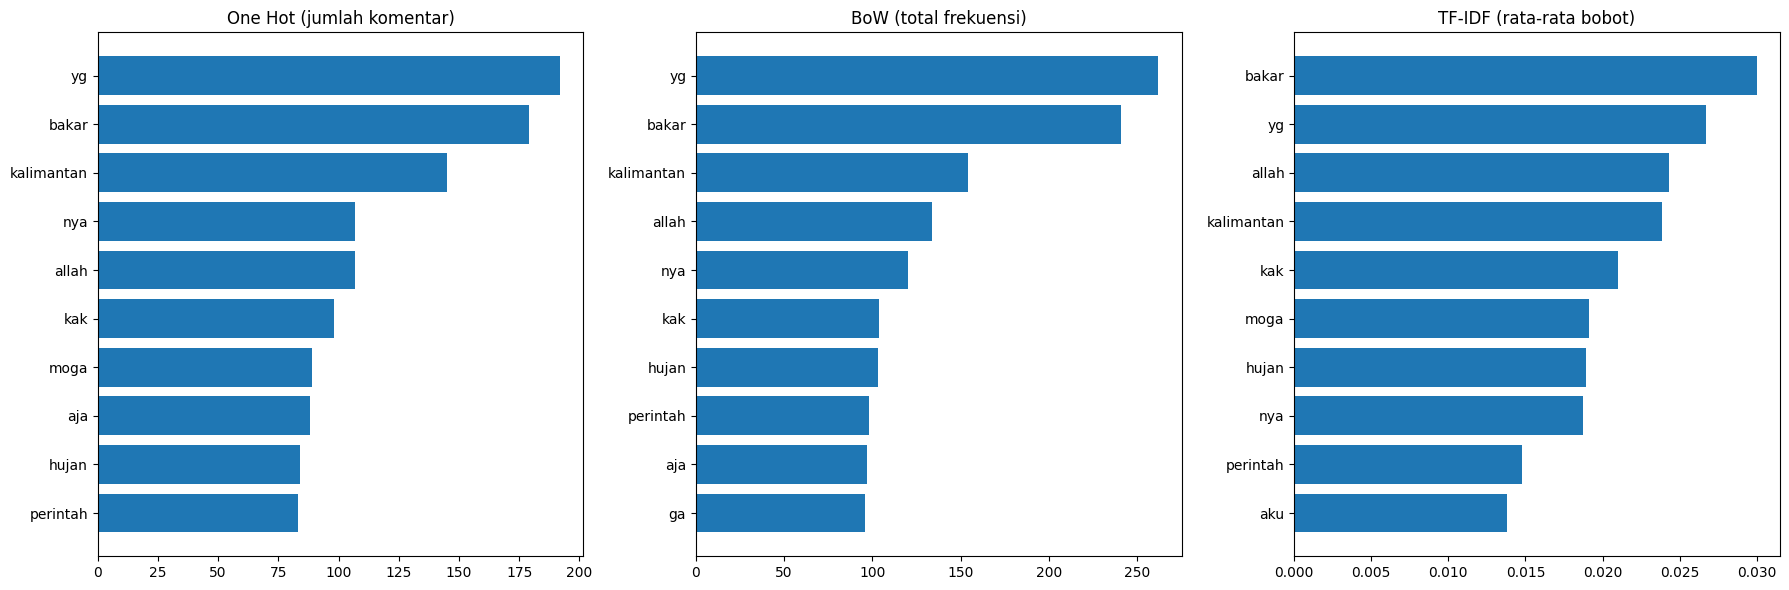

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, serie, judul in zip(
    axes,
    [top_ohe.head(10), top_bow.head(10), top_tfidf.head(10)],
    ['One Hot (jumlah komentar)', 'BoW (total frekuensi)', 'TF-IDF (rata-rata bobot)']
):
    ax.barh(serie.index[::-1], serie.values[::-1])
    ax.set_title(judul)
plt.tight_layout()
plt.show()

**Kata paling umum dan paling langka (IDF)**

In [31]:
idf = pd.Series(tfidf_vec.idf_, index=tfidf_vec.get_feature_names_out()).sort_values()

print("10 kata paling UMUM (IDF terendah):")
display(idf.head(10).to_frame('IDF'))

print("10 kata paling LANGKA (IDF tertinggi):")
display(idf.tail(10).to_frame('IDF'))

10 kata paling UMUM (IDF terendah):


,IDF
yg,2.880927
bakar,2.950661
kalimantan,3.160011
allah,3.461486
nya,3.461486
kak,3.548498
moga,3.643808
aja,3.654981
hujan,3.700966
perintah,3.712801


10 kata paling LANGKA (IDF tertinggi):


,IDF
agikk,7.45047
afrika,7.45047
afkterkekeh,7.45047
aff,7.45047
yups,7.45047
yuu,7.45047
abadi,7.45047
zamanada,7.45047
aamiinsemoga,7.45047
aaku,7.45047


**Contoh satu komentar dalam tiga representasi**

In [32]:
idx = 0
kata_ada = df_bow.columns[df_bow.iloc[idx] > 0]

contoh = pd.DataFrame({
    'One Hot': df_ohe.loc[idx, kata_ada],
    'BoW': df_bow.loc[idx, kata_ada],
    'TF-IDF': df_tfidf.loc[idx, kata_ada].round(4)
})

print("Komentar asli :", df.loc[idx, 'text_original'])
print("Setelah prepro:", df.loc[idx, 'prepro'])
contoh

Komentar asli : AGUSTUS JAHAT.
Setelah prepro: agustus jahat


,One Hot,BoW,TF-IDF
agustus,1,1,0.7316
jahat,1,1,0.6818


**4. Word2Vec**

Setiap kata diubah menjadi vektor 100 dimensi berdasarkan kata-kata di sekitarnya. Vektor satu komentar diperoleh dari rata-rata vektor kata-kata di dalamnya.

**Latih Word2Vec**

In [33]:
sentences = [t.split() for t in docs]

w2v_model = gensim.models.Word2Vec(
    sentences, min_count=1, vector_size=100, window=5, sg=0, epochs=50, seed=42
)
w2v = w2v_model.wv

print("Jumlah kata di vocabulary:", len(w2v.index_to_key))
print("10 kata teratas:", w2v.index_to_key[:10])

Jumlah kata di vocabulary: 3000
10 kata teratas: ['yg', 'bakar', 'kalimantan', 'allah', 'nya', 'kak', 'hujan', 'perintah', 'aja', 'gak']


**Kata mirip + vektor komentar (Word2Vec)**

In [35]:
kata_uji = w2v.index_to_key[0]
print(f"Kata paling mirip dengan '{kata_uji}' (Word2Vec):")
display(pd.DataFrame(w2v.most_similar(kata_uji, topn=5), columns=['Kata', 'Cosine similarity']))

def doc_vector(tokens, wv):
    vecs = [wv[w] for w in tokens if w in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(wv.vector_size)

X_w2v = np.array([doc_vector(t, w2v) for t in sentences])
df_w2v = pd.DataFrame(X_w2v)

print("Ukuran matriks Word2Vec:", df_w2v.shape)
df_w2v.head(1200)

Kata paling mirip dengan 'yg' (Word2Vec):


,Kata,Cosine similarity
0,nolongin,0.970281
1,oknum,0.970128
2,libat,0.968976
3,hti,0.968938
4,belukar,0.968276


Ukuran matriks Word2Vec: (1265, 100)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.210052,-0.092197,-0.384975,0.137934,-0.442348,0.552132,0.409157,0.243902,0.015763,-0.117246,...,-0.477023,0.316500,0.150212,-0.583156,0.421657,-0.205802,-0.278293,0.077503,-0.235474,-0.487032
1,0.263506,0.160390,-0.231828,0.048614,-0.206982,0.338168,0.273549,0.346706,-0.424699,-0.115519,...,-0.567472,0.692171,0.342780,-0.415859,0.408716,-0.367223,-0.036127,0.287846,0.038986,-0.397110
2,0.314397,0.147840,-0.130112,0.057410,-0.389556,0.309934,0.342572,0.387153,-0.287553,-0.262483,...,-0.564490,0.707881,0.313943,-0.378247,0.563446,-0.197844,-0.038270,0.241889,-0.057682,-0.549822
3,0.382599,0.225266,-0.158943,0.057827,-0.599456,0.235012,0.337250,0.415737,0.097933,-0.329606,...,-0.570713,0.581175,0.341301,-0.390400,0.598719,0.033763,0.090049,0.110350,-0.201473,-0.609313
4,0.675638,0.186820,-0.321482,0.282553,-1.006278,0.045898,0.368690,0.654205,0.559662,-0.195909,...,-1.007466,0.669686,0.437455,-0.532439,0.339910,0.034652,0.682497,-0.014720,-0.728101,-0.641161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,0.165735,-0.020005,-0.271020,0.076717,-0.294566,0.312281,0.251024,0.268555,-0.123753,-0.007608,...,-0.468783,0.454039,0.187017,-0.431537,0.291969,-0.241551,-0.014339,0.158611,-0.164043,-0.190224
1196,0.142862,-0.024713,-0.271993,0.069103,-0.187363,0.292187,0.217522,0.291087,-0.206359,0.044603,...,-0.495463,0.434151,0.131001,-0.409592,0.266293,-0.273287,-0.027965,0.148225,-0.165800,-0.061253
1197,0.130417,-0.060321,-0.245829,-0.052039,-0.147861,0.427171,0.315080,0.358647,-0.176732,0.034237,...,-0.470476,0.469136,0.153607,-0.515859,0.393167,-0.348151,-0.106848,0.188088,-0.145071,-0.150623
1198,0.169402,0.019573,-0.282387,0.093373,-0.307773,0.320880,0.251411,0.308542,-0.105025,-0.015592,...,-0.560497,0.435500,0.101503,-0.449298,0.268585,-0.202182,-0.028157,0.147727,-0.246916,-0.099003


**5. FastText**

Mirip Word2Vec, tetapi memakai n-gram karakter (3 sampai 6 huruf). Dengan begitu kata yang jarang muncul atau salah ketik tetap memiliki vektor.

**Latih FastText**

In [36]:
ft_model = gensim.models.FastText(
    sentences, min_count=1, vector_size=100, window=5,
    min_n=3, max_n=6, sg=1, epochs=50, seed=42
)
ft = ft_model.wv

print("Jumlah kata di vocabulary:", len(ft.index_to_key))
print(f"Kata paling mirip dengan '{kata_uji}' (FastText):")
display(pd.DataFrame(ft.most_similar(kata_uji, topn=5), columns=['Kata', 'Cosine similarity']))

Jumlah kata di vocabulary: 3000
Kata paling mirip dengan 'yg' (FastText):


,Kata,Cosine similarity
0,afrika,0.587365
1,sadarin,0.580098
2,izin,0.579857
3,masyarakat,0.579148
4,berontak,0.577278


**Vektor komentar (FastText)**

In [37]:
X_ft = np.array([doc_vector(t, ft) for t in sentences])
df_ft = pd.DataFrame(X_ft)

print("Ukuran matriks FastText:", df_ft.shape)
df_ft.head(1200)

Ukuran matriks FastText: (1265, 100)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.275726,0.242645,-0.011983,-0.207451,0.473014,1.046063,0.450288,-0.280046,-0.652185,-0.131070,...,0.273903,-0.663305,0.053155,-0.282878,0.232910,-0.005343,-0.329091,0.591936,-0.025716,0.131298
1,0.060540,-0.265899,-0.518693,-0.278484,0.256507,0.698624,0.131900,-0.062055,-0.065473,-0.223413,...,0.206604,0.204211,0.254076,0.179465,-0.109327,-0.499112,-0.075287,0.653416,-0.365044,-0.136775
2,0.368393,0.133111,-0.304562,-0.306624,0.567072,0.600007,0.444512,-0.001497,-0.158396,-0.501006,...,-0.254570,-0.008572,0.188615,0.205626,0.208771,-0.405323,-0.295342,0.316661,-0.437222,-0.133529
3,0.298321,0.199284,-0.560106,-0.062392,0.770480,0.492705,0.515623,0.200294,-0.406524,-0.450852,...,-0.173086,-0.401703,0.068484,0.401900,0.332912,-0.355258,-0.099893,0.376652,-0.072680,0.143996
4,0.442913,0.377230,-0.348291,0.163804,0.384053,0.285598,0.346171,0.160487,-0.167368,-0.378461,...,0.116753,-0.254203,0.382408,0.468833,0.103883,-0.279526,-0.198191,0.203535,0.129260,0.239477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,0.074188,0.098897,-0.129732,-0.038971,0.359254,0.625931,0.186164,0.020352,-0.117063,-0.120222,...,0.074388,-0.203667,0.088707,0.078894,-0.036725,-0.380327,-0.076006,0.146206,0.035763,0.110879
1196,0.174602,0.113092,0.251137,0.097086,0.399911,0.606037,0.441302,0.127170,-0.145814,-0.048649,...,-0.245115,-0.068549,0.347038,0.094116,0.022605,-0.341981,0.015011,0.136512,-0.142527,0.484698
1197,0.010906,-0.006530,0.202665,-0.276748,0.153482,0.879414,0.309774,0.264408,0.016990,-0.138580,...,0.014453,-0.384169,0.454718,0.119001,0.155562,-0.063671,-0.210303,0.392139,-0.214358,0.314584
1198,0.165701,0.093937,0.210503,-0.029266,0.225533,0.737624,0.205588,-0.087204,-0.144846,0.010610,...,-0.207896,-0.146489,0.197253,-0.015334,0.025541,-0.322841,-0.053074,0.204671,0.046982,0.188348


**Perbandingan Word2Vec vs FastText untuk 3 kata teratas**

In [38]:
for kata in w2v.index_to_key[:3]:
    print(f"\n=== {kata} ===")
    hasil = pd.DataFrame({
        'Word2Vec': [k for k, _ in w2v.most_similar(kata, topn=5)],
        'FastText': [k for k, _ in ft.most_similar(kata, topn=5)],
    })
    display(hasil)


=== yg ===


,Word2Vec,FastText
0,nolongin,afrika
1,oknum,sadarin
2,libat,izin
3,hti,masyarakat
4,belukar,berontak



=== bakar ===


,Word2Vec,FastText
0,lahan,bakarr
1,ilegal,akar
2,malas,ngebakar
3,sdri,dibakarknp
4,kartuhla,ular



=== kalimantan ===


,Word2Vec,FastText
0,jawa,kalimantann
1,guys,kalimantancm
2,garagara,kalimanta
3,hendak,kalimantanku
4,amin,kalimantanbutuh


**Perbandingan kelima metode + simpan hasil**

In [39]:
perbandingan = pd.DataFrame({
    'Metode': ['One Hot', 'Bag of Words', 'TF-IDF', 'Word2Vec', 'FastText'],
    'Jumlah dokumen': [df_ohe.shape[0], df_bow.shape[0], df_tfidf.shape[0], df_w2v.shape[0], df_ft.shape[0]],
    'Jumlah fitur': [df_ohe.shape[1], df_bow.shape[1], df_tfidf.shape[1], df_w2v.shape[1], df_ft.shape[1]],
    'Jenis': ['Biner, sparse', 'Frekuensi, sparse', 'Berbobot, sparse', 'Vektor padat', 'Vektor padat'],
})

df_tfidf.to_csv('tiktok_tfidf.csv', index=False)
df_w2v.to_csv('tiktok_word2vec.csv', index=False)
df_ft.to_csv('tiktok_fasttext.csv', index=False)

perbandingan

,Metode,Jumlah dokumen,Jumlah fitur,Jenis
0,One Hot,1265,2986,"Biner, sparse"
1,Bag of Words,1265,2986,"Frekuensi, sparse"
2,TF-IDF,1265,2986,"Berbobot, sparse"
3,Word2Vec,1265,100,Vektor padat
4,FastText,1265,100,Vektor padat


**ANALISIS HASIL**

1. **One Hot Encoding** hanya mencatat ada atau tidaknya kata dalam komentar (0/1). Dari 1265 komentar diperoleh 2986 fitur. Kata yang paling banyak ditemukan adalah "yg" pada 192 komentar, diikuti "bakar" (179 komentar) dan "kalimantan" (145 komentar). Kelemahannya, jumlah kemunculan kata dalam satu komentar tidak terbaca.

2. **Bag of Words** menghitung frekuensi kata sehingga kata yang diulang mendapat nilai lebih besar. Kata dengan total frekuensi tertinggi adalah "yg" (262 kali), lalu "bakar" (241 kali) dan "kalimantan" (154 kali). Kata "yg" muncul 262 kali tetapi hanya di 192 komentar, artinya sebagian komentar mengulang kata tersebut. Kelemahannya, kata yang umum di banyak komentar tetap bernilai tinggi walau kurang membedakan satu komentar dengan yang lain.

3. **TF-IDF** menurunkan bobot kata yang muncul di banyak komentar dan menaikkan bobot kata yang khas. Urutan teratas berubah dibanding BoW: "bakar" (0,0300) berada di atas "yg" (0,0267), disusul "allah", "kalimantan", dan "kak". Kata paling umum ("yg") memiliki IDF 2,88, sedangkan kata paling langka, seperti "aaku", "abadi", dan "afrika", memiliki IDF 7,45 karena hanya muncul di satu komentar. Dengan demikian kata langka menjadi ciri yang lebih kuat bagi komentarnya.

4. **Sparsity**: sekitar 99,7% sel pada matriks One Hot, BoW, dan TF-IDF bernilai 0. Hal ini wajar karena komentar TikTok pendek sehingga tiap komentar hanya memuat sedikit kata dari 2986 kata unik.

5. **Word2Vec** menghasilkan vektor padat 100 dimensi untuk 3000 kata. Kata terdekat dengan "bakar" adalah "lahan", "ilegal", dan "malas", yang relevan dengan topik pembakaran lahan. Namun, untuk kata fungsi informal seperti "yg", tetangga terdekatnya ("nolongin", "oknum", "libat") kurang bermakna. Sebagian tetangga lain juga tampak acak (misalnya "sdri", "kartuhla"), yang menunjukkan data komentar yang pendek dan terbatas membuat kualitas vektor kata belum optimal.

6. **FastText** juga menghasilkan vektor 100 dimensi, tetapi memakai n-gram karakter. Kata terdekat dengan "bakar" adalah "bakarr", "akar", "ngebakar", dan "dibakarknp", sedangkan untuk "kalimantan" adalah "kalimantann", "kalimantancm", dan "kalimanta". Artinya FastText menangkap kemiripan bentuk penulisan, termasuk salah ketik dan imbuhan yang banyak ditemukan pada komentar TikTok. Word2Vec sebaliknya menangkap kata dengan konteks yang sama (misalnya "kalimantan" dengan "jawa"). Keduanya saling melengkapi.

7. **Catatan jumlah fitur**: kosakata scikit-learn (2986 kata) berbeda dengan Gensim (3000 kata). Selisih ini kemungkinan berasal dari token satu huruf yang diabaikan CountVectorizer secara bawaan tetapi tetap dihitung oleh Gensim.

8. **Temuan preprocessing**: kata informal seperti "yg", "nya", "kak", dan "gak" masih mendominasi karena tidak termasuk dalam daftar stopword Sastrawi. Untuk perbaikan, kata-kata ini dapat ditambahkan sebagai stopword tambahan pada tahap preprocessing.

9. **Kesimpulan**: One Hot dan BoW sederhana tetapi tidak membedakan kata penting dan kata umum. TF-IDF lebih informatif untuk analisis berbasis kata, sedangkan Word2Vec dan FastText mewakili komentar dengan hanya 100 dimensi, jauh lebih ringkas dari 2986 fitur. Untuk tahap selanjutnya (similarity dan clustering), TF-IDF dan vektor FastText layak dipakai.